# __scPortrait workflow with DAPI Cellpose Segmentation method__

In [1]:
# check the shape and dtype of the tif file
import tifffile

tif_file_path = "../data/processed/breast-cancer-rep1-10x-xenium-bundle_cropped_morphology_focus_rescaled.ome.tif"

img = tifffile.imread(tif_file_path)

y, x = img.shape

print(f"Image shape: {y} x {x} pixels")
print(img.dtype)

Image shape: 4500 x 4000 pixels
uint16


## scPortrait Project Structure (Initialization)

In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np

from scportrait.pipeline.segmentation.workflows import DAPISegmentationCellpose # Segmentation workflow using Cellpose algorithm for DAPI-stained (nuclear stained) images
from scportrait.pipeline.featurization import CellFeaturizer
from scportrait.pipeline.extraction import HDF5CellExtraction
from scportrait.pipeline.project import Project

import yaml
from IPython.display import Markdown

In [3]:
# Generate the project structure for cropped dataset from 01_prepare_xenium_data.ipynb

project_location = "../data/interim/10x_xenium_breast_cancer_rep1_dapicellpose_segmentation_cropped_project"
config_file = "../configs/dapi_cellpose_segmentation_config.yml"
project = Project(
    os.path.abspath(project_location),
    config_path=config_file,
    overwrite=True,
    debug=True,
    segmentation_f=DAPISegmentationCellpose,
    extraction_f=HDF5CellExtraction,
    featurization_f=CellFeaturizer
)

Updating project config file.
[10/07/2026 22:40:14] Loading config from /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapicellpose_segmentation_cropped_project/config.yml
[10/07/2026 22:40:14] No cache directory specified in config using current working directory /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks.
[10/07/2026 22:40:14] Compression algorithm for extracted single-cell images: lzf
[10/07/2026 22:40:14] No cache directory specified in config using current working directory /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks.


/tmp/ipykernel_1524432/363704388.py:5: UserWarning: There is already a directory in the location path
  project = Project(


In [4]:
# Import the cropped Xenium dataset into the project structure

tif_file_path = "../data/processed/breast-cancer-rep1-10x-xenium-bundle_cropped_morphology_focus_rescaled.ome.tif"

project.load_input_from_tif_files(file_paths = [tif_file_path], 
                                  channel_names=["DAPI_cellpose"],
                                  crop=[(0, y), (0, x)],
                                  overwrite=True)

[10/07/2026 22:40:17] Output location /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapicellpose_segmentation_cropped_project/scportrait.sdata already exists. Overwriting.
[10/07/2026 22:40:17] Initialized temporary directory at /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks/Project_fhr8k7as for Project
[10/07/2026 22:40:20] Image input_image written to sdata object.
[10/07/2026 22:40:20] Cleaned up temporary directory at <TemporaryDirectory '/scratch/tmurugan/scportrait-spatial-omics-qc/notebooks/Project_fhr8k7as'>


In [5]:
project.print_project_status()

[10/07/2026 22:40:41] Current Project Status:
[10/07/2026 22:40:41] --------------------------------
[10/07/2026 22:40:41] Input Image in sdata: True
[10/07/2026 22:40:41] Nucleus Segmentation in sdata: False
[10/07/2026 22:40:41] Cytosol Segmentation in sdata: False
[10/07/2026 22:40:41] Nucleus Centers in sdata: False
[10/07/2026 22:40:41] Cytosol Centers in sdata: False
[10/07/2026 22:40:41] Extracted single-cell images saved to file: False
[10/07/2026 22:40:41] --------------------------------


In [6]:
# Inspect the project object
project.sdata

SpatialData object, with associated Zarr store: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapicellpose_segmentation_cropped_project/scportrait.sdata
└── Images
      └── 'input_image': DataTree[cyx] (1, 4500, 4000), (1, 2250, 2000), (1, 562, 500), (1, 70, 62)
with coordinate systems:
    ▸ 'global', with elements:
        input_image (Images)

In [7]:
project.input_image

<xarray.DataArray 'image' (c: 1, y: 4500, x: 4000)> Size: 36MB
dask.array<from-zarr, shape=(1, 4500, 4000), dtype=uint16, chunksize=(1, 256, 256), chunktype=numpy.ndarray>
Coordinates:
  * c        (c) <U13 52B 'DAPI_cellpose'
  * y        (y) float64 36kB 0.5 1.5 2.5 3.5 ... 4.498e+03 4.498e+03 4.5e+03
  * x        (x) float64 32kB 0.5 1.5 2.5 3.5 ... 3.998e+03 3.998e+03 4e+03
Attributes:
    transform:  {'global': Identity }

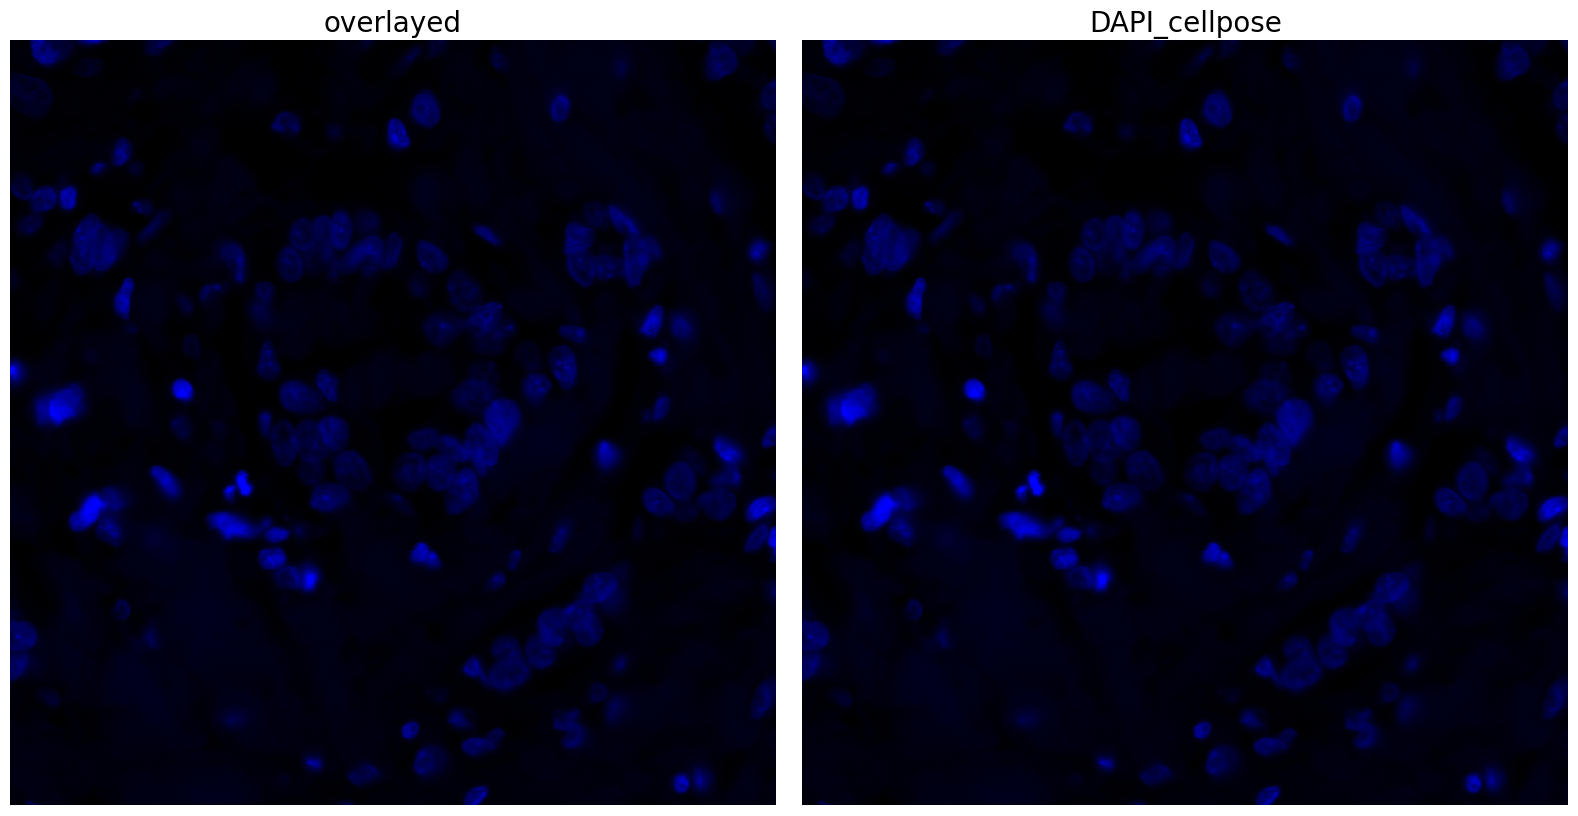

In [8]:
project.plot_input_image()

## Segmentation - DAPI Cellpose

In [9]:
display(Markdown(f"```yaml\n{yaml.dump(project.segmentation_f.config, default_flow_style=False)}\n```"))

```yaml
cache: /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks
chunk_size: 50
nucleus_segmentation:
  flow_threshold: 0.6
  model: nuclei

```

In [10]:
print(project.input_image.shape)
print(project.input_image.dtype)

(1, 4500, 4000)
uint16


In [11]:
project.segment()

[10/07/2026 22:41:46] GPU Status for segmentation is False and will segment using the following device cpu.
[10/07/2026 22:41:47] Segmenting nucleus using the following model: nuclei


/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/site-packages/cellpose/dynamics.py:760: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


[10/07/2026 22:43:12] Segmentation seg_all_nucleus written to sdata object.
[10/07/2026 22:43:16] Points centers_seg_all_nucleus written to sdata object.


In [12]:
# SpatialData object after segmentation
project.sdata

SpatialData object, with associated Zarr store: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapicellpose_segmentation_cropped_project/scportrait.sdata
├── Images
│     └── 'input_image': DataTree[cyx] (1, 4500, 4000), (1, 2250, 2000), (1, 562, 500), (1, 70, 62)
├── Labels
│     └── 'seg_all_nucleus': DataTree[yx] (4500, 4000), (2250, 2000), (562, 500), (70, 62)
└── Points
      └── 'centers_seg_all_nucleus': DataFrame with shape: (<Delayed>, 2) (2D points)
with coordinate systems:
    ▸ 'global', with elements:
        input_image (Images), seg_all_nucleus (Labels), centers_seg_all_nucleus (Points)

In [13]:
# Compute the number of segmented nuclei
from skimage.measure import regionprops

nuc = project.sdata.labels["seg_all_nucleus"]["scale0"]["image"].data.compute()

print(len(regionprops(nuc)))

3737


In [14]:
# Compute the segmented nuclei area statistics
areas = [r.area for r in regionprops(nuc)]

print("Count:", len(areas))
print("Median:", np.median(areas))
print("5th percentile:", np.percentile(areas, 5))
print("95th percentile:", np.percentile(areas, 95))

Count: 3737
Median: 757.0
5th percentile: 190.0
95th percentile: 2208.7999999999993


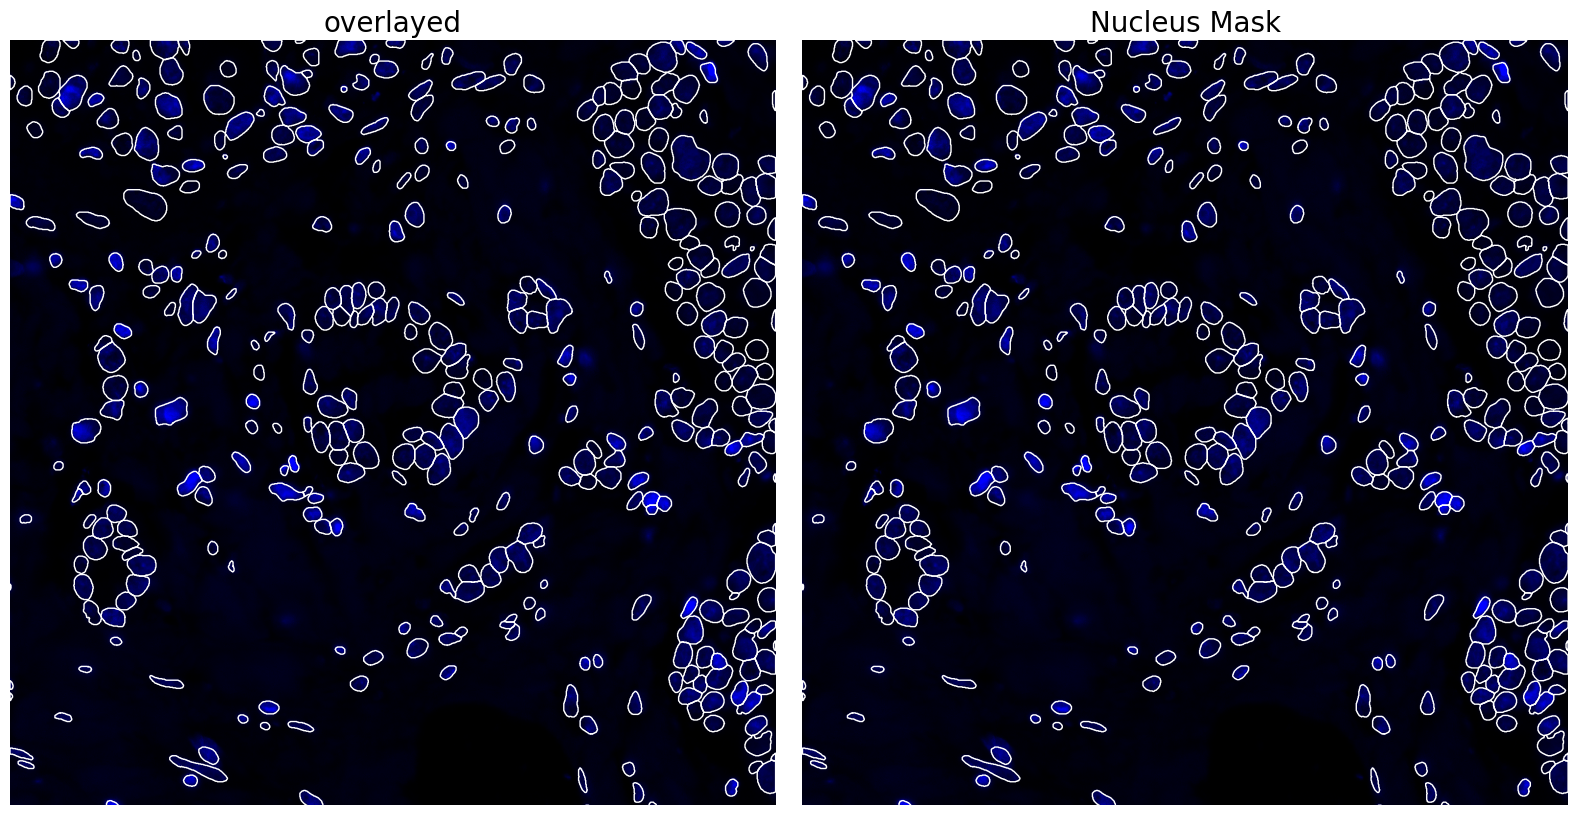

In [15]:
project.plot_segmentation_masks()

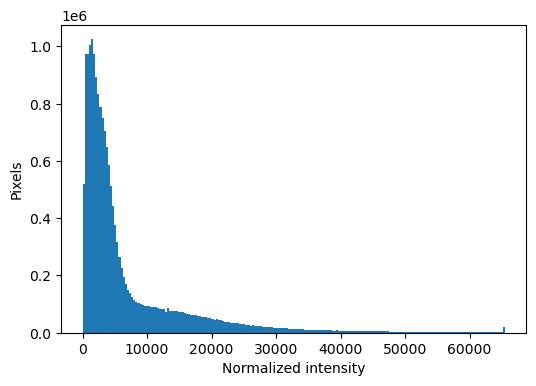

In [16]:
# Plot the histogram of pixel intensities in the DAPI channel
img = project.input_image[0].data.compute() # turns the dask array into a numpy array

plt.figure(figsize=(6,4))
plt.hist(img.ravel(), bins=200)
plt.xlabel("Normalized intensity")
plt.ylabel("Pixels")
plt.show()

## Single-cell extraction

In [17]:
# Extracting single cell images (cell segmentation only, no nucleus segmentation masks)
display(Markdown(f"```yaml\n{yaml.dump(project.extraction_f.config, default_flow_style=False)}\n```"))

```yaml
cache: .
compression: true
image_size: 64
normalize_output: false
segmentation_mask: seg_all_nucleus
threads: 8

```

In [18]:
project.extract()

[10/07/2026 22:53:57] Initialized temporary directory at ./HDF5CellExtraction_aynud8r0 for HDF5CellExtraction
[10/07/2026 22:53:57] Created new directory for extraction results: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapicellpose_segmentation_cropped_project/extraction/data
[10/07/2026 22:53:57] Setup output folder at /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapicellpose_segmentation_cropped_project/extraction/data
[10/07/2026 22:53:57] Found 1 segmentation masks for the given key in the sdata object. Will be extracting single-cell images based on these masks: ['seg_all_nucleus']
[10/07/2026 22:53:57] Using seg_all_nucleus as the main segmentation mask to determine cell centers.
[10/07/2026 22:53:57] A total of 45 cells were too close to the image border to be extracted. Their cell_ids were saved to file /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_re

Extracting cell batches:   0%|          | 0/8 [00:00<?, ?it/s]

[10/07/2026 22:54:00] Finished extraction in 2.00 seconds (1849.39 cells / second)
[10/07/2026 22:54:01] Benchmarking times saved to file.
[10/07/2026 22:54:01] Cleaned up temporary directory at ./HDF5CellExtraction_aynud8r0


In [19]:
# Show the created AnnData object after single cell image extraction
project.h5sc

AnnData object with n_obs × n_vars = 3692 × 2
    obs: 'scportrait_cell_id'
    var: 'channels', 'channel_mapping'
    uns: 'single_cell_images'
    obsm: 'single_cell_images'

In [20]:
display("Single cell image dataset:", project.h5sc.obsm["single_cell_images"])
display("Metadata:", project.h5sc.uns["single_cell_images"])

'Single cell image dataset:'

<HDF5 dataset "single_cell_images": shape (3692, 2, 64, 64), type "<f2">

'Metadata:'

{'channel_mapping': array(['mask', 'image_channel'], dtype=object),
 'channel_names': array(['seg_all_nucleus', 'DAPI_cellpose'], dtype=object),
 'compression': 'lzf',
 'image_size': 64,
 'n_cells': 3692,
 'n_channels': 2,
 'n_image_channels': 1,
 'n_masks': 1,
 'normalization': False,
 'normalization_range_lower': 'None',
 'normalization_range_upper': 'None'}

In [21]:
project.h5sc.obs

,scportrait_cell_id
0,29
1,30
2,31
3,33
4,34
...,...
3687,3801
3688,3802
3689,3804
3690,3806


In [22]:
project.h5sc.var

,channels,channel_mapping
0,seg_all_nucleus,mask
1,DAPI_cellpose,image_channel


(2, 64, 64)


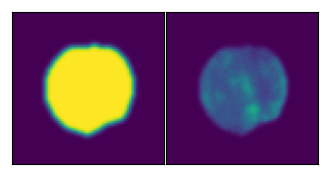

In [23]:
# Visualize the extracted single cell images for a specific cell ID
import scportrait

cell_id = 2502
image_of_cell = scportrait.tl.h5sc.get_image_with_cellid(project.h5sc, cell_id)
print(image_of_cell.shape)
fig, axs = plt.subplots(1, 1, figsize=(2 * 2, 2))
scportrait.pl.h5sc._plot_image_grid(ax=axs, images=image_of_cell, nrows=1, ncols=2)

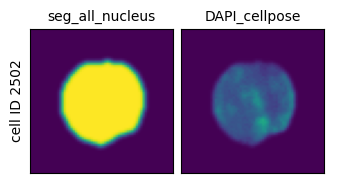

In [24]:
scportrait.pl.cell_grid(project.h5sc, cell_ids=cell_id)

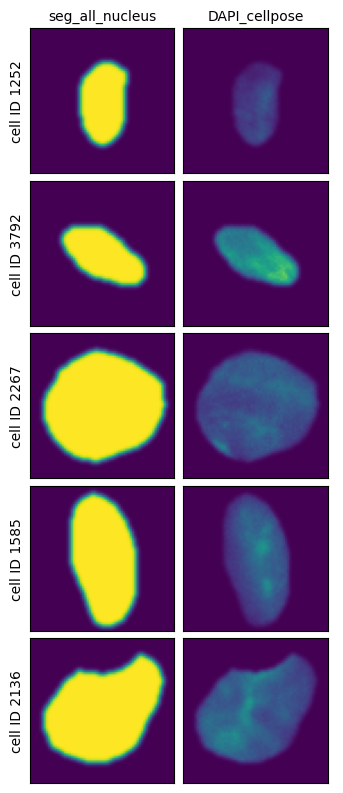

In [25]:
# Visualize the extracted single cell images for randomly selected cell IDs
project.plot_single_cell_images()


## Featurization

In [26]:
display(Markdown(f"```yaml\n{yaml.dump(project.featurization_f.config, default_flow_style=False)}\n```"))

```yaml
batch_size: 900
cache: /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks
dataloader_worker_number: 0
inference_device: cpu

```

In [27]:
project.featurize(overwrite = True)

Using extraction directory: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapicellpose_segmentation_cropped_project/extraction/data/single_cells.h5sc
[10/07/2026 23:05:36] Initialized temporary directory at /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks/CellFeaturizer_00tfz904 for CellFeaturizer
[10/07/2026 23:05:36] Started CellFeaturization of all available channels.
[10/07/2026 23:05:36] Created new directory for featurization results: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapicellpose_segmentation_cropped_project/featurization/complete_CellFeaturizer
[10/07/2026 23:05:36] Initialized temporary directory at /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks/CellFeaturizer_kghpfqxe for CellFeaturizer
[10/07/2026 23:05:36] Reading data from path: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapicellpose_segmentation_cropped_project/ext

/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWar

[10/07/2026 23:05:37] Table CellFeaturizer_nucleus written to sdata object.
[10/07/2026 23:05:38] GPU memory before performing cleanup: None
[10/07/2026 23:05:38] GPU memory after performing cleanup: None
[10/07/2026 23:05:38] Cleaned up temporary directory at /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks/CellFeaturizer_kghpfqxe


In [28]:
# Examine the SpatialData object after featurization
project.sdata

SpatialData object, with associated Zarr store: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapicellpose_segmentation_cropped_project/scportrait.sdata
├── Images
│     └── 'input_image': DataTree[cyx] (1, 4500, 4000), (1, 2250, 2000), (1, 562, 500), (1, 70, 62)
├── Labels
│     └── 'seg_all_nucleus': DataTree[yx] (4500, 4000), (2250, 2000), (562, 500), (70, 62)
├── Points
│     └── 'centers_seg_all_nucleus': DataFrame with shape: (<Delayed>, 2) (2D points)
└── Tables
      └── 'CellFeaturizer_nucleus': AnnData (3692, 7)
with coordinate systems:
    ▸ 'global', with elements:
        input_image (Images), seg_all_nucleus (Labels), centers_seg_all_nucleus (Points)

In [29]:
# View the extracted features for the segmented nuclei
results = project.sdata["CellFeaturizer_nucleus"].to_df()
print(results.head())

   nucleus_area  DAPI_cellpose_mean_nucleus  DAPI_cellpose_median_nucleus  \
0        3529.0                    0.381485                      0.400879   
1        1402.0                    0.104319                      0.089447   
2        1577.0                    0.156377                      0.201782   
3        1822.0                    0.062198                      0.084503   
4        2063.0                    0.152794                      0.188599   

   DAPI_cellpose_quant75_nucleus  DAPI_cellpose_quant25_nucleus  \
0                       0.560547                       0.182861   
1                       0.186066                       0.000505   
2                       0.253174                       0.005726   
3                       0.099548                       0.003680   
4                       0.239990                       0.011295   

   DAPI_cellpose_summed_intensity_nucleus  \
0                             1346.260376   
1                              146.255112   

In [30]:
results["nucleus_area"].describe()

count    3692.000000
mean     1504.761353
std       757.836548
min       153.000000
25%       963.000000
50%      1328.500000
75%      1971.250000
max      4083.000000
Name: nucleus_area, dtype: float64

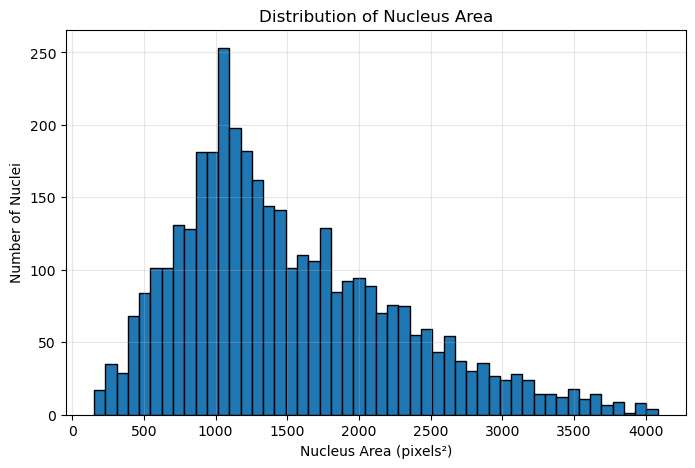

In [31]:
# Plot the histogram of nucleus area

plt.figure(figsize=(8, 5))

plt.hist(results["nucleus_area"], bins=50, edgecolor="black")

plt.title("Distribution of Nucleus Area")
plt.xlabel("Nucleus Area (pixels²)")
plt.ylabel("Number of Nuclei")

plt.grid(alpha=0.3)
plt.show()

## Clustering (based on nuclei features from `CellFeaturizer`)

In [32]:
# Keep only numeric features
X = results.select_dtypes(include=np.number)

print(X.shape)
X.head()

(3692, 7)


,nucleus_area,DAPI_cellpose_mean_nucleus,DAPI_cellpose_median_nucleus,DAPI_cellpose_quant75_nucleus,DAPI_cellpose_quant25_nucleus,DAPI_cellpose_summed_intensity_nucleus,DAPI_cellpose_summed_intensity_area_normalized_nucleus
0,3529.0,0.381485,0.400879,0.560547,0.182861,1346.260376,0.381485
1,1402.0,0.104319,0.089447,0.186066,0.000505,146.255112,0.104319
2,1577.0,0.156377,0.201782,0.253174,0.005726,246.607025,0.156377
3,1822.0,0.062198,0.084503,0.099548,0.003680,113.325195,0.062198
4,2063.0,0.152794,0.188599,0.239990,0.011295,315.215057,0.152794


In [33]:
# Create an AnnData object for the extracted features
import anndata as ad

adata_feat = ad.AnnData(X)
adata_feat.obs_names = results.index.astype(str)

In [34]:
# Perform dimensional reduction and clustering based on the extracted features
import scanpy as sc
from sklearn.preprocessing import StandardScaler

adata_feat.X = StandardScaler().fit_transform(adata_feat.X)

sc.tl.pca(adata_feat)
sc.pp.neighbors(adata_feat, n_neighbors=15, n_pcs=20)
sc.tl.umap(adata_feat)
sc.tl.leiden(
    adata_feat,
    resolution=0.5,
    key_added="morphology_cluster_label"
)

adata_feat.obs["morphology_cluster_label"].value_counts()

/tmp/ipykernel_1524432/3374749162.py:10: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


morphology_cluster_label
0     389
1     356
2     337
3     333
4     317
5     260
6     242
7     235
8     227
9     207
10    192
11    173
12    156
13    142
14    126
Name: count, dtype: int64

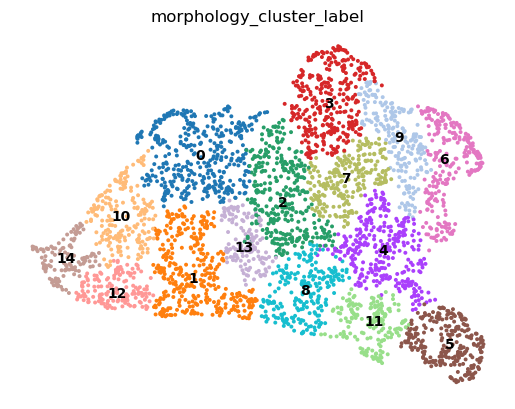

In [35]:
# Visualize the UMAP embedding colored by 'morphology_cluster_label'
sc.pl.umap(
    adata_feat,
    color="morphology_cluster_label",
    legend_loc="on data",
    frameon=False,
)

In [36]:
# Inspect the SpatialData object (to append the cluster labels to the 'tables' element of the SpatialData object)
print(project.sdata) 
print(project.sdata.tables)

SpatialData object, with associated Zarr store: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapicellpose_segmentation_cropped_project/scportrait.sdata
├── Images
│     └── 'input_image': DataTree[cyx] (1, 4500, 4000), (1, 2250, 2000), (1, 562, 500), (1, 70, 62)
├── Labels
│     └── 'seg_all_nucleus': DataTree[yx] (4500, 4000), (2250, 2000), (562, 500), (70, 62)
├── Points
│     └── 'centers_seg_all_nucleus': DataFrame with shape: (<Delayed>, 2) (2D points)
└── Tables
      └── 'CellFeaturizer_nucleus': AnnData (3692, 7)
with coordinate systems:
    ▸ 'global', with elements:
        input_image (Images), seg_all_nucleus (Labels), centers_seg_all_nucleus (Points)
{'CellFeaturizer_nucleus': AnnData object with n_obs × n_vars = 3692 × 7
    obs: 'scportrait_cell_id', 'region'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'}


In [37]:
# Create a copy of the 'CellFeaturizer_nucleus' table and add the 'morphology_cluster_label' to it
feat_adata = project.sdata.tables["CellFeaturizer_nucleus"].copy()
feat_adata.obs["morphology_cluster_label"] = (
    adata_feat.obs.loc[feat_adata.obs_names, "morphology_cluster_label"].values
)

In [38]:
# Create a new SpatialData object with all the elements and the updated table and write it to a new path
from pathlib import Path
from spatialdata import SpatialData

output_path = Path("../data/results/xenium_dapi_cellpose_cellfeaturizer.sdata.zarr")
output_path.parent.mkdir(parents=True, exist_ok=True)

sdata_result = SpatialData(
    images=dict(project.sdata.images),
    labels=dict(project.sdata.labels),
    points=dict(project.sdata.points),
    shapes=dict(project.sdata.shapes),
    tables={
        "CellFeaturizer_nucleus": feat_adata,
    },
)

sdata_result.write(output_path)

/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWar